# TASK # 1

In [1]:
# -------------------------------
# Example Tree Structure (Graph Form)
#
#        0
#       / \
#      1   2
#     / \  / \
#    3   4 5  6
# -------------------------------

# Node class for tree
class Node:
    def __init__(self, value):
        self.value = value
        self.left = None
        self.right = None

# BFS function (level by level traversal)
def bfs(root):
    queue = [root]  # start with root node
    while queue:
        node = queue.pop(0)  # remove first element
        print(node.value, end=" ")
        if node.left: queue.append(node.left)   # add left child
        if node.right: queue.append(node.right) # add right child

# DFS function (depth first traversal)
def dfs(root):
    if root:
        print(root.value, end=" ")
        dfs(root.left)   # go left
        dfs(root.right)  # then right

# Build the tree
root = Node(0)
root.left = Node(1)
root.right = Node(2)
root.left.left = Node(3)
root.left.right = Node(4)
root.right.left = Node(5)
root.right.right = Node(6)

print("BFS Traversal:")
bfs(root)   # Output: 0 1 2 3 4 5 6
print("\nDFS Traversal:")
dfs(root)   # Output: 0 1 3 4 2 5 6


BFS Traversal:
0 1 2 3 4 5 6 
DFS Traversal:
0 1 3 4 2 5 6 

# Task # 2

   Tree Size    BFS Time  DFS Time
0       1000    0.000400  0.000221
1      40000    0.511345  0.002298
2      80000    1.790802  0.001041
3     200000    8.842795  0.021984
4    1000000  131.794459  0.123764


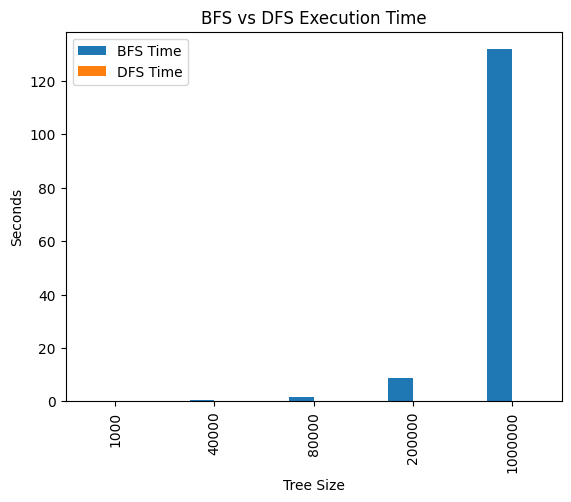

In [3]:
import random
import time
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------
# Helper: Node class for tree
# -------------------------------
class Node:
    def __init__(self, value):
        self.value = value
        self.left = None
        self.right = None

# -------------------------------
# Build a binary search tree from list
# -------------------------------
def insert(root, value):
    if root is None:
        return Node(value)
    if value < root.value:
        root.left = insert(root.left, value)
    else:
        root.right = insert(root.right, value)
    return root

def build_tree(values):
    root = None
    for v in values:
        root = insert(root, v)
    return root

# -------------------------------
# BFS Search
# -------------------------------
def bfs_search(root, goal):
    queue = [root]
    while queue:
        node = queue.pop(0)
        if node.value == goal:
            return True
        if node.left: queue.append(node.left)
        if node.right: queue.append(node.right)
    return False

# -------------------------------
# DFS Search
# -------------------------------
def dfs_search(root, goal):
    if root is None:
        return False
    if root.value == goal:
        return True
    return dfs_search(root.left, goal) or dfs_search(root.right, goal)

# -------------------------------
# Experiment Setup
# -------------------------------
sizes = [1000, 40000, 80000, 200000, 1000000]
results = []

for size in sizes:
    # Generate random unique numbers
    values = random.sample(range(size*2), size)
    root = build_tree(values)

    # Goal element
    goal = values[-220]

    # BFS timing
    start = time.time()
    bfs_search(root, goal)
    bfs_time = time.time() - start

    # DFS timing
    start = time.time()
    dfs_search(root, goal)
    dfs_time = time.time() - start

    results.append([size, bfs_time, dfs_time])

# -------------------------------
# DataFrame of results
# -------------------------------
df = pd.DataFrame(results, columns=["Tree Size", "BFS Time", "DFS Time"])
print(df)

# -------------------------------
# Plot bar chart
# -------------------------------
df.plot(x="Tree Size", y=["BFS Time", "DFS Time"], kind="bar")
plt.ylabel("Seconds")
plt.title("BFS vs DFS Execution Time")
plt.show()


# Task # 3

In [4]:
from collections import deque

# -------------------------------
# Graph of Cities (Adjacency List)
# -------------------------------
graph = {
    "Islamabad": ["Rawalpindi", "Lahore", "Peshawar"],
    "Rawalpindi": ["Islamabad", "Peshawar", "Quetta"],
    "Peshawar": ["Islamabad", "Rawalpindi", "Quetta"],
    "Lahore": ["Islamabad", "Multan", "Quetta"],
    "Multan": ["Lahore", "Karachi", "Quetta"],
    "Quetta": ["Rawalpindi", "Peshawar", "Lahore", "Multan", "Karachi"],
    "Karachi": ["Multan", "Quetta"]
}

# -------------------------------
# BFS Shortest Path Function
# -------------------------------
def bfs_shortest_path(graph, start, goal):
    visited = set()
    queue = deque([[start]])   # queue stores paths

    while queue:
        path = queue.popleft()
        city = path[-1]

        if city == goal:
            return path   # shortest path found

        if city not in visited:
            for neighbor in graph[city]:
                new_path = list(path)
                new_path.append(neighbor)
                queue.append(new_path)
            visited.add(city)
    return None

# -------------------------------
# Run BFS
# -------------------------------
shortest_path = bfs_shortest_path(graph, "Islamabad", "Karachi")
print("Shortest path from Islamabad to Karachi:", shortest_path)


Shortest path from Islamabad to Karachi: ['Islamabad', 'Rawalpindi', 'Quetta', 'Karachi']


# youtube link
https://youtube.com/@bint-e-hawa7771?si=zCO-ZJsjNxA6kAP0

# github link
https://github.com/tsajid245